In [1]:
import scanpy as sc
import pandas as pd
from sklearn import metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import SEDRp

In [2]:
random_seed = 2023
SEDRp.fix_seed(random_seed)

In [ ]:
# gpu
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

adata = sc.read_visium("/work/data1/cyx/spatialLIBD/151510/",
                       count_file='151510_filtered_feature_bc_matrix.h5',
                       source_image_path='/work/data1/cyx/spatialLIBD/151510/spatial/tissue_lowres_image.png')
adata.var_names_make_unique()

adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [ ]:
graph_dict = SEDRp.graph_construction(adata, 12)
print(graph_dict)

sedr_net = SEDRp.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(N=1)
else:
    sedr_net.train_without_dec(N=1)
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat

In [ ]:
import numpy as np
def mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR', random_seed=2023):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """
    # import os
    # os.environ['R_HOME'] = '/scbio4/tools/R/R-4.0.3_openblas/R-4.0.3'
    modelNames = 'EEE'

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[use_rep]), n_clusters, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs[key_added] = mclust_res
    adata.obs[key_added] = adata.obs[key_added].astype('int')
    adata.obs[key_added] = adata.obs[key_added].astype('category')

    return adata

In [ ]:
n_clusters = 7
mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR')

In [46]:
true = pd.read_csv('/work/data1/cyx/spatialLIBD/151510/cluster_labels_151510.csv', index_col=0)

In [47]:
common_index = true.index.intersection(adata.obs['SEDR'].index)
common_index

Index(['AAACAAGTATCTCCCA-1', 'AAACACCAATAACTGC-1', 'AAACAGAGCGACTCCT-1',
       'AAACAGCTTTCAGAAG-1', 'AAACAGGGTCTATATT-1', 'AAACAGTGTTCCTGGG-1',
       'AAACATGGTGAGAGGA-1', 'AAACATTTCCCGGATT-1', 'AAACCCGAACGAAATC-1',
       'AAACCGGAAATGTTAA-1',
       ...
       'TTGTTAGCAAATTCGA-1', 'TTGTTCAGTGTGCTAC-1', 'TTGTTCTAGATACGCT-1',
       'TTGTTGGCAATGACTG-1', 'TTGTTGTGTGTCAAGA-1', 'TTGTTTCACATCCAGG-1',
       'TTGTTTCATTAGTCTA-1', 'TTGTTTCCATACAACT-1', 'TTGTTTGTATTACACG-1',
       'TTGTTTGTGTAAATTC-1'],
      dtype='object', length=4595)

In [48]:
adata.obs['SEDR'].to_csv('SEDRp_151510.csv', index=True) 

In [49]:
true_common = true.loc[common_index]
pre_common = adata.obs['SEDR'].loc[common_index]

In [51]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, fowlkes_mallows_score, completeness_score, homogeneity_score, accuracy_score
# 如果是DataFrame中的一列数据，使用.squeeze()方法将其转为1D
labels_true = true_common.squeeze()
labels_pred = pre_common.squeeze()

# 计算ARI
ari = adjusted_rand_score(labels_true, labels_pred)

# 计算NMI
nmi = normalized_mutual_info_score(labels_true, labels_pred)

# 计算AMI
ami = adjusted_mutual_info_score(labels_true, labels_pred)

# 计算FMI
fmi = fowlkes_mallows_score(labels_true, labels_pred)

# 计算COMP (Completeness)
comp = completeness_score(labels_true, labels_pred)

# 计算HOMO (Homogeneity)
homo = homogeneity_score(labels_true, labels_pred)

# 计算ACC (Accuracy)
acc = accuracy_score(labels_true, labels_pred)

# 输出结果
print(f"ARI: {ari}")
print(f"NMI: {nmi}")
print(f"AMI: {ami}")
print(f"FMI: {fmi}")
print(f"COMP: {comp}")
print(f"HOMO: {homo}")
print(f"ACC: {acc}")

ARI: 0.5533291537893446
NMI: 0.6565368110186126
AMI: 0.6557290788601069
FMI: 0.6559849075686978
COMP: 0.6314262693140607
HOMO: 0.6837272568918458
ACC: 0.1632208922742111


[<AxesSubplot: title={'center': 'SEDR'}, xlabel='spatial1', ylabel='spatial2'>]

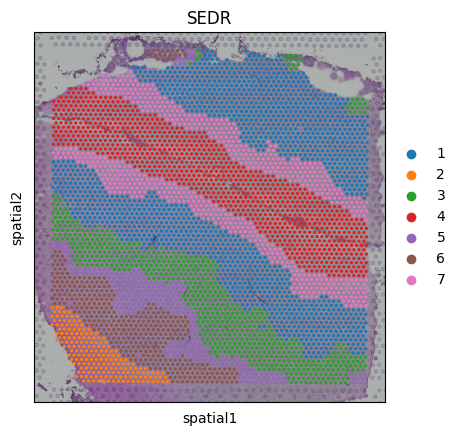

In [52]:
sc.pl.spatial(adata, color='SEDR', show=False)

In [62]:
import scanpy as sc
import pandas as pd
from sklearn import metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import SEDRp

random_seed = 2023
SEDRp.fix_seed(random_seed)

# gpu
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

adata = sc.read_visium("/work/data1/cyx/spatialLIBD/151672/",
                       count_file='151672_filtered_feature_bc_matrix.h5',
                       source_image_path='/work/data1/cyx/spatialLIBD/151672/spatial/tissue_lowres_image.png')
adata.var_names_make_unique()

adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X
graph_dict = SEDRp.graph_construction(adata, 12)
print(graph_dict)

sedr_net = SEDRp.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(N=1)
else:
    sedr_net.train_without_dec(N=1)
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat


import numpy as np
def mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR', random_seed=2023):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """
    # import os
    # os.environ['R_HOME'] = '/scbio4/tools/R/R-4.0.3_openblas/R-4.0.3'
    modelNames = 'EEE'

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[use_rep]), n_clusters, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs[key_added] = mclust_res
    adata.obs[key_added] = adata.obs[key_added].astype('int')
    adata.obs[key_added] = adata.obs[key_added].astype('category')

    return adata

n_clusters = 5
mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR')

{'adj_norm': tensor(indices=tensor([[   0,  428,  526,  ..., 3759, 3931, 4014],
                       [   0,    0,    0,  ..., 4014, 4014, 4014]]),
       values=tensor([0.0769, 0.0769, 0.0769,  ..., 0.0769, 0.0769, 0.0769]),
       size=(4015, 4015), nnz=53447, layout=torch.sparse_coo), 'adj_label': tensor(indices=tensor([[   0,    0,    0,  ..., 4014, 4014, 4014],
                       [   0,  428,  526,  ..., 3759, 3931, 4014]]),
       values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
       size=(4015, 4015), nnz=53447, dtype=torch.float64,
       layout=torch.sparse_coo), 'norm_value': 0.5016632768561313}


100%|█████████████████████████████████████████| 200/200 [00:03<00:00, 56.78it/s]


fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 4015 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'SEDR'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'X_pca', 'SEDR'
    layers: 'count'

In [63]:
true = pd.read_csv('/work/data1/cyx/spatialLIBD/151672/cluster_labels_151672.csv', index_col=0)
common_index = true.index.intersection(adata.obs['SEDR'].index)
common_index
adata.obs['SEDR'].to_csv('SEDRp_151672.csv', index=True) 
true_common = true.loc[common_index]
pre_common = adata.obs['SEDR'].loc[common_index]

import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, fowlkes_mallows_score, completeness_score, homogeneity_score, accuracy_score
# 如果是DataFrame中的一列数据，使用.squeeze()方法将其转为1D
labels_true = true_common.squeeze()
labels_pred = pre_common.squeeze()

# 计算ARI
ari = adjusted_rand_score(labels_true, labels_pred)

# 计算NMI
nmi = normalized_mutual_info_score(labels_true, labels_pred)

# 计算AMI
ami = adjusted_mutual_info_score(labels_true, labels_pred)

# 计算FMI
fmi = fowlkes_mallows_score(labels_true, labels_pred)

# 计算COMP (Completeness)
comp = completeness_score(labels_true, labels_pred)

# 计算HOMO (Homogeneity)
homo = homogeneity_score(labels_true, labels_pred)

# 计算ACC (Accuracy)
acc = accuracy_score(labels_true, labels_pred)

# 输出结果
print(f"ARI: {ari}")
print(f"NMI: {nmi}")
print(f"AMI: {ami}")
print(f"FMI: {fmi}")
print(f"COMP: {comp}")
print(f"HOMO: {homo}")
print(f"ACC: {acc}")

ARI: 0.5853904394975158
NMI: 0.6926868856072651
AMI: 0.6922640637294809
FMI: 0.6888622613125981
COMP: 0.6694597952239376
HOMO: 0.7175836461376902
ACC: 0.046553497942386834


[<AxesSubplot: title={'center': 'SEDR'}, xlabel='spatial1', ylabel='spatial2'>]

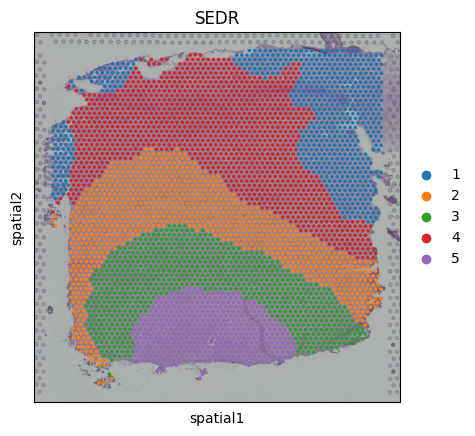

In [64]:
sc.pl.spatial(adata, color='SEDR', show=False)

In [11]:
import scanpy as sc
import pandas as pd
from sklearn import metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import SEDRp

random_seed = 2023
SEDRp.fix_seed(random_seed)

# gpu
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

adata = sc.read_visium("/work/data1/cyx/spatialLIBD/151676/",
                       count_file='151676_filtered_feature_bc_matrix.h5',
                       source_image_path='/work/data1/cyx/spatialLIBD/151676/spatial/tissue_lowres_image.png')
adata.var_names_make_unique()

adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X
graph_dict = SEDRp.graph_construction(adata, 12)
print(graph_dict)

sedr_net = SEDRp.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(N=1)
else:
    sedr_net.train_without_dec(N=1)
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat


import numpy as np
def mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR', random_seed=2023):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """
    # import os
    # os.environ['R_HOME'] = '/scbio4/tools/R/R-4.0.3_openblas/R-4.0.3'
    modelNames = 'EEE'

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[use_rep]), n_clusters, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs[key_added] = mclust_res
    adata.obs[key_added] = adata.obs[key_added].astype('int')
    adata.obs[key_added] = adata.obs[key_added].astype('category')

    return adata

n_clusters = 7
mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR')

{'adj_norm': tensor(indices=tensor([[   0,  397,  486,  ..., 3434, 3595, 3672],
                       [   0,    0,    0,  ..., 3672, 3672, 3672]]),
       values=tensor([0.0769, 0.0769, 0.0769,  ..., 0.0769, 0.0769, 0.0769]),
       size=(3673, 3673), nnz=48963, layout=torch.sparse_coo), 'adj_label': tensor(indices=tensor([[   0,    0,    0,  ..., 3672, 3672, 3672],
                       [   0,  397,  486,  ..., 3434, 3595, 3672]]),
       values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
       size=(3673, 3673), nnz=48963, dtype=torch.float64,
       layout=torch.sparse_coo), 'norm_value': 0.5018212737630791}


100%|█████████████████████████████████████████| 200/200 [00:04<00:00, 49.13it/s]


fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 3673 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'SEDR'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'X_pca', 'SEDR'
    layers: 'count'

In [12]:
true = pd.read_csv('/work/data1/cyx/spatialLIBD/151676/cluster_labels_151676.csv', index_col=0)
common_index = true.index.intersection(adata.obs['SEDR'].index)
common_index
adata.obs['SEDR'].to_csv('SEDRp_151676.csv', index=True) 
true_common = true.loc[common_index]
pre_common = adata.obs['SEDR'].loc[common_index]

import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, fowlkes_mallows_score, completeness_score, homogeneity_score, accuracy_score
# 如果是DataFrame中的一列数据，使用.squeeze()方法将其转为1D
labels_true = true_common.squeeze()
labels_pred = pre_common.squeeze()

# 计算ARI
ari = adjusted_rand_score(labels_true, labels_pred)

# 计算NMI
nmi = normalized_mutual_info_score(labels_true, labels_pred)

# 计算AMI
ami = adjusted_mutual_info_score(labels_true, labels_pred)

# 计算FMI
fmi = fowlkes_mallows_score(labels_true, labels_pred)

# 计算COMP (Completeness)
comp = completeness_score(labels_true, labels_pred)

# 计算HOMO (Homogeneity)
homo = homogeneity_score(labels_true, labels_pred)

# 计算ACC (Accuracy)
acc = accuracy_score(labels_true, labels_pred)

# 输出结果
print(f"ARI: {ari}")
print(f"NMI: {nmi}")
print(f"AMI: {ami}")
print(f"FMI: {fmi}")
print(f"COMP: {comp}")
print(f"HOMO: {homo}")
print(f"ACC: {acc}")

ARI: 0.5987915238590925
NMI: 0.7172483326429694
AMI: 0.7164806763208141
FMI: 0.6666263866250787
COMP: 0.7183651751908344
HOMO: 0.7161349574153318
ACC: 0.11581843191196699


[<AxesSubplot: title={'center': 'SEDR'}, xlabel='spatial1', ylabel='spatial2'>]

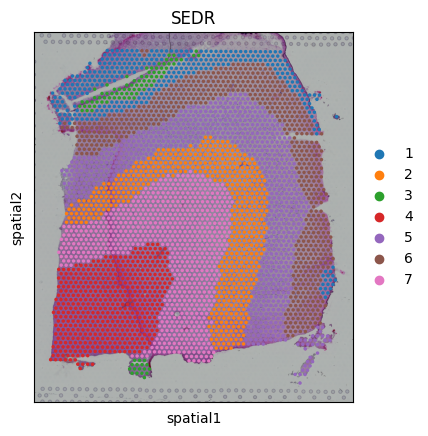

In [13]:
sc.pl.spatial(adata, color='SEDR', show=False)

In [42]:
import scanpy as sc
import pandas as pd
from sklearn import metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import SEDRp

random_seed = 2023
SEDRp.fix_seed(random_seed)

# gpu
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

adata = sc.read_visium("/work/data1/cyx/spatialLIBD/3.Human_Breast_Cancer/",
                       count_file='filtered_feature_bc_matrix.h5',
                       source_image_path='/work/data1/cyx/spatialLIBD/3.Human_Breast_Cancer/spatial/tissue_lowres_image.png')
adata.var_names_make_unique()

adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X
graph_dict = SEDRp.graph_construction(adata, 12)
print(graph_dict)

sedr_net = SEDRp.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(N=1)
else:
    sedr_net.train_without_dec(N=1)
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat


import numpy as np
def mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR', random_seed=2023):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """
    # import os
    # os.environ['R_HOME'] = '/scbio4/tools/R/R-4.0.3_openblas/R-4.0.3'
    modelNames = 'EEE'

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[use_rep]), n_clusters, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs[key_added] = mclust_res
    adata.obs[key_added] = adata.obs[key_added].astype('int')
    adata.obs[key_added] = adata.obs[key_added].astype('category')

    return adata

n_clusters = 20
mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR')

{'adj_norm': tensor(indices=tensor([[   0,  397,  487,  ..., 3563, 3717, 3797],
                       [   0,    0,    0,  ..., 3797, 3797, 3797]]),
       values=tensor([0.0769, 0.0769, 0.0769,  ..., 0.0769, 0.0769, 0.0769]),
       size=(3798, 3798), nnz=50780, layout=torch.sparse_coo), 'adj_label': tensor(indices=tensor([[   0,    0,    0,  ..., 3797, 3797, 3797],
                       [   0,  397,  487,  ..., 3563, 3717, 3797]]),
       values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
       size=(3798, 3798), nnz=50780, dtype=torch.float64,
       layout=torch.sparse_coo), 'norm_value': 0.5017663807991416}


100%|█████████████████████████████████████████| 200/200 [00:03<00:00, 50.33it/s]


fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 3798 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'SEDR'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'X_pca', 'SEDR'
    layers: 'count'

In [43]:
true = pd.read_csv('/work/data1/cyx/spatialLIBD/3.Human_Breast_Cancer/Breast_annotation.csv', index_col=0)
common_index = true.index.intersection(adata.obs['SEDR'].index)
common_index
adata.obs['SEDR'].to_csv('SEDRp_breast.csv', index=True) 
true_common = true.loc[common_index]
pre_common = adata.obs['SEDR'].loc[common_index]

import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, fowlkes_mallows_score, completeness_score, homogeneity_score, accuracy_score
# 如果是DataFrame中的一列数据，使用.squeeze()方法将其转为1D
labels_true = true_common.squeeze()
labels_pred = pre_common.squeeze()

# 计算ARI
ari = adjusted_rand_score(labels_true, labels_pred)

# 计算NMI
nmi = normalized_mutual_info_score(labels_true, labels_pred)

# 计算AMI
ami = adjusted_mutual_info_score(labels_true, labels_pred)

# 计算FMI
fmi = fowlkes_mallows_score(labels_true, labels_pred)

# 计算COMP (Completeness)
comp = completeness_score(labels_true, labels_pred)

# 计算HOMO (Homogeneity)
homo = homogeneity_score(labels_true, labels_pred)

# 计算ACC (Accuracy)
acc = accuracy_score(labels_true, labels_pred)

# 输出结果
print(f"ARI: {ari}")
print(f"NMI: {nmi}")
print(f"AMI: {ami}")
print(f"FMI: {fmi}")
print(f"COMP: {comp}")
print(f"HOMO: {homo}")
print(f"ACC: {acc}")

ARI: 0.3720713277224066
NMI: 0.6420944124314765
AMI: 0.6355334137964694
FMI: 0.41806366706156756
COMP: 0.6317857065149973
HOMO: 0.6527451082126492
ACC: 0.04870984728804634


[<AxesSubplot: title={'center': 'SEDR'}, xlabel='spatial1', ylabel='spatial2'>]

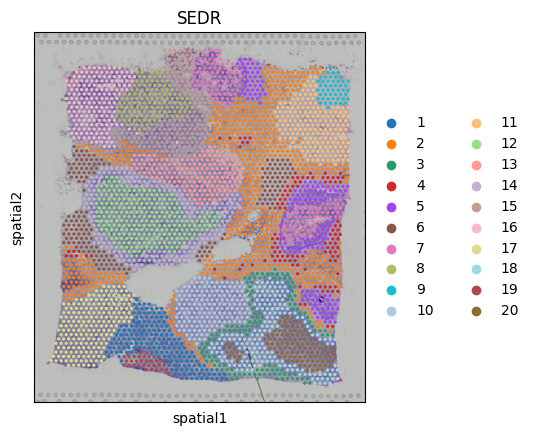

In [44]:
sc.pl.spatial(adata, color='SEDR', show=False)

In [50]:
import scanpy as sc
import pandas as pd
from sklearn import metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import SEDRp

random_seed = 2023
SEDRp.fix_seed(random_seed)

# gpu
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

adata = sc.read_visium("/work/data1/cyx/spatialLIBD/3.Human_Breast_Cancer/Section2/",
                       count_file='V1_Breast_Cancer_Block_A_Section_2_filtered_feature_bc_matrix.h5',
                       source_image_path='/work/data1/cyx/spatialLIBD/3.Human_Breast_Cancer/Section2/spatial/tissue_lowres_image.png')
adata.var_names_make_unique()

adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X
graph_dict = SEDRp.graph_construction(adata, 12)
print(graph_dict)

sedr_net = SEDRp.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(N=1)
else:
    sedr_net.train_without_dec(N=1)
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat


import numpy as np
def mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR', random_seed=2023):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """
    # import os
    # os.environ['R_HOME'] = '/scbio4/tools/R/R-4.0.3_openblas/R-4.0.3'
    modelNames = 'EEE'

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[use_rep]), n_clusters, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs[key_added] = mclust_res
    adata.obs[key_added] = adata.obs[key_added].astype('int')
    adata.obs[key_added] = adata.obs[key_added].astype('category')

    return adata

n_clusters = 30
mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR')

{'adj_norm': tensor(indices=tensor([[   0,  777, 1038,  ..., 3737, 3906, 3986],
                       [   0,    0,    0,  ..., 3986, 3986, 3986]]),
       values=tensor([0.0769, 0.0716, 0.0693,  ..., 0.0769, 0.0769, 0.0769]),
       size=(3987, 3987), nnz=53143, layout=torch.sparse_coo), 'adj_label': tensor(indices=tensor([[   0,    0,    0,  ..., 3986, 3986, 3986],
                       [   0,  777, 1038,  ..., 3737, 3906, 3986]]),
       values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
       size=(3987, 3987), nnz=53143, dtype=torch.float64,
       layout=torch.sparse_coo), 'norm_value': 0.5016771732874767}


100%|█████████████████████████████████████████| 200/200 [00:03<00:00, 50.32it/s]

fitting ...
  |                                                                      |   0%

  |======================================================================| 100%


AnnData object with n_obs × n_vars = 3987 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'SEDR'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'X_pca', 'SEDR'
    layers: 'count'

[<AxesSubplot: title={'center': 'SEDR'}, xlabel='spatial1', ylabel='spatial2'>]

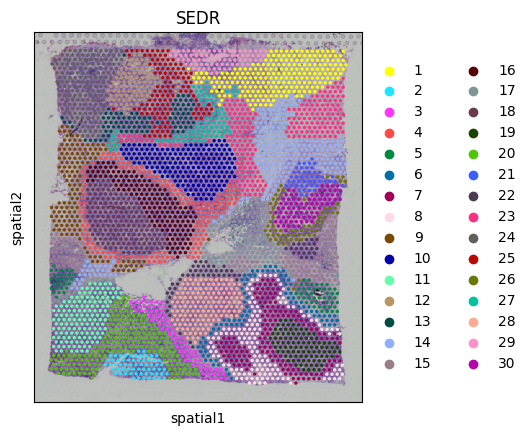

In [51]:
sc.pl.spatial(adata, color='SEDR', show=False)

In [52]:
adata.obs['SEDR'].to_csv('SEDRp_breast_30_section2.csv', index=True) 